# Purpose:
- Running another round of landmark extension.
- Based on the 2nd iteration, where now most of the cells are matched.
    - Use the same logic as the first round - find 5 nearest cells, and choose the one with the highest gene counts
    - Check many-to-one matching


In [1]:
import os
import zarr
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import Rbf
from scipy.spatial import distance_matrix
import cv2
import os
import json
from pathlib import Path

DATA_DIR = Path('/root/capsule/data/')

%load_ext autoreload
%autoreload 2

In [2]:
def get_ids_from_landmarks(landmarks):
    columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
    assert len(landmarks.columns) == len(columns)
    if not all([a==b for a,b in zip(landmarks.columns, columns)]):
        landmarks.columns = columns
    matched_ids = landmarks['ids'].values
    def _get_ids(x):
        if x.startswith('cz'):
            cz_id = int(x.split('-')[0].split('cz')[-1])
            hcr_id = int(x.split('-')[1].split('hcr')[-1])
            return cz_id, hcr_id
        else:
            return -1
    
    ids = [_get_ids(x) for x in matched_ids]
    ids = [id for id in ids if id != -1]
    zstack_ids = [id[0] for id in ids]
    hcr_ids = [id[1] for id in ids]
    return zstack_ids, hcr_ids

In [3]:
subject_id = 755252
save_dir = Path('/root/capsule/scratch/755252_2024-12-19_coreg_cpsam/')
filepaths_json = save_dir / '755252_2024-12-19_filepaths.json'
with open(filepaths_json, 'r') as f:
    filepaths_dict = json.load(f)
for key in filepaths_dict:
    filepaths_dict[key] = Path(filepaths_dict[key])
    assert filepaths_dict[key].exists()
print(filepaths_dict.keys())
# make variables named after each filepath
for key in filepaths_dict:
    globals()[key] = filepaths_dict[key]
hcr_dir = fused_json_file.parent

dict_keys(['czstack_reg_path', 'czstack_reg_dim_swapped_path', 'czstack_seg_path', 'czstack_seg_outline_path', 'czstack_centroid_path', 'hcr_centroid_path', 'fused_json_file'])


In [4]:
# Data loading
# Find spot data
spots_488_path = hcr_dir / 'image_spot_detection/channel_488_spots/spots.csv'
if spots_488_path.exists():
    spots_488 = pd.read_csv(spots_488_path)
    spot_488_counts = pd.DataFrame(spots_488['SEG_ID'].value_counts())
    spot_488_counts.rename(columns={'SEG_ID': 'hcr_id'}, inplace=True)
    spot_488_bounding_box_min = spots_488.groupby('SEG_ID').agg({'X':'min','Y':'min','Z':'min'}).rename(columns={'X':'min_x','Y':'min_y','Z':'min_z'})
    spot_488_bounding_box_max = spots_488.groupby('SEG_ID').agg({'X':'max','Y':'max','Z':'max'}).rename(columns={'X':'max_x','Y':'max_y','Z':'max_z'})
    spot_488_bounding_box = pd.concat([spot_488_bounding_box_min, spot_488_bounding_box_max], axis=1)
    spot_488_bounding_box['bb_volume'] = (spot_488_bounding_box['max_x'] - spot_488_bounding_box['min_x'] + 1) * (spot_488_bounding_box['max_y'] - spot_488_bounding_box['min_y'] + 1) * (spot_488_bounding_box['max_z'] - spot_488_bounding_box['min_z'] + 1)
    spot_488_counts = spot_488_counts.merge(spot_488_bounding_box[['bb_volume']], left_index=True, right_index=True)
    spot_488_counts['density'] = spot_488_counts['count'] / spot_488_counts['bb_volume']
    spot_488_counts.set_index('hcr_id', inplace=True)
else:
    spots_path = DATA_DIR / f'cell_data_mean_{subject_id}_R1.csv'
    assert spots_path.exists(), f'No spot_depetection processing nor {spots_path} for {subject_id}'
    spot_488_counts = pd.read_csv(spots_path).query('channel==488')
    spot_488_counts.rename(columns={'cell_id': 'hcr_id', 'mean': 'density'}, inplace=True)
    spot_488_counts.set_index('hcr_id', inplace=True)


# Get HCR centroid and scales
with open(fused_json_file, 'r') as file:
    data = json.load(file)
scale_x = data['dimensions']['x'][0]*4e6
scale_y = data['dimensions']['y'][0]*4e6
scale_z = data['dimensions']['z'][0]*1e6

HCR_cell_centroids = np.load(hcr_centroid_path)

HCR_cell_ids = HCR_cell_centroids[:,3]
HCR_cell_centroids = HCR_cell_centroids[:,:-1]

HCR_cell_centroids_df = pd.DataFrame()
HCR_cell_centroids_df['hcr_cell_id'] = HCR_cell_ids
HCR_cell_centroids_df['hcr_z'] = HCR_cell_centroids[:,0]
HCR_cell_centroids_df['hcr_y'] = HCR_cell_centroids[:,1]
HCR_cell_centroids_df['hcr_x'] = HCR_cell_centroids[:,2]
HCR_cell_centroids_df.set_index('hcr_cell_id', inplace=True)


# Get cortical z-stack centroids
czstack_cell_centroids_df = pd.read_csv(czstack_centroid_path, index_col=0)


In [5]:
# Get landmarks from the previous iteration
# Apply the transformation to the leftover cells
current_iter = 4
prev_iter = current_iter - 1
filter_hcr_rois = True # if current_iter == 2 else False

# landmarks_file = next(save_dir.glob(f'{subject_id}_landmarks_matched_ext_iter{prev_iter}.csv'))
landmarks_file = next(save_dir.glob(f'{subject_id}_landmarks_matched_ext_iter{prev_iter}_reordered_qced.csv'))

landmarks = pd.read_csv(landmarks_file, header=None)
columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
landmarks.columns = columns
landmarks = landmarks.query('active')

points_zstack = landmarks[['czstack_x', 'czstack_y', 'czstack_z']].values.astype(np.float32)
points_HCR = landmarks[['hcr_x', 'hcr_y', 'hcr_z']].values.astype(np.float32)

matched_czstack_ids, matched_hcr_ids = get_ids_from_landmarks(landmarks)
leftover_czstack_ids = list(set(czstack_cell_centroids_df.index) - set(matched_czstack_ids))
leftover_czstack_df = czstack_cell_centroids_df.loc[leftover_czstack_ids]
leftover_czstack_cell_centroids = np.vstack(leftover_czstack_df[['czstack_x','czstack_y','czstack_z']].values)

interp_zstacktoHCR_0 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,0],
                           function='thin_plate')
interp_zstacktoHCR_1 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,1],
                           function='thin_plate')
interp_zstacktoHCR_2 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,2],
                           function='thin_plate')

HCR_centroids_est = np.zeros_like(leftover_czstack_cell_centroids)

HCR_centroids_est[:,0] = interp_zstacktoHCR_0(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_x
HCR_centroids_est[:,1] = interp_zstacktoHCR_1(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_y
HCR_centroids_est[:,2] = interp_zstacktoHCR_2(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_z

# HCR_centroids_est[:,0] = interp_zstacktoHCR_0(leftover_czstack_cell_centroids[:, 0],
#                                               leftover_czstack_cell_centroids[:, 1],
#                                               leftover_czstack_cell_centroids[:, 2])
# HCR_centroids_est[:,1] = interp_zstacktoHCR_1(leftover_czstack_cell_centroids[:, 0],
#                                               leftover_czstack_cell_centroids[:, 1],
#                                               leftover_czstack_cell_centroids[:, 2])
# HCR_centroids_est[:,2] = interp_zstacktoHCR_2(leftover_czstack_cell_centroids[:, 0],
#                                               leftover_czstack_cell_centroids[:, 1],
#                                               leftover_czstack_cell_centroids[:, 2])
print(f'Previously matched cells: {len(matched_czstack_ids)}')
print(f'New estimation: {HCR_centroids_est.shape[0]}')
print(f'{HCR_centroids_est.shape[0] / (len(matched_czstack_ids) + HCR_centroids_est.shape[0]) * 100:.1f}% of total czstack cells have been matched after {current_iter} iterations')

Previously matched cells: 630
New estimation: 205
24.6% of total czstack cells have been matched after 4 iterations


## Where are the leftover centroids?

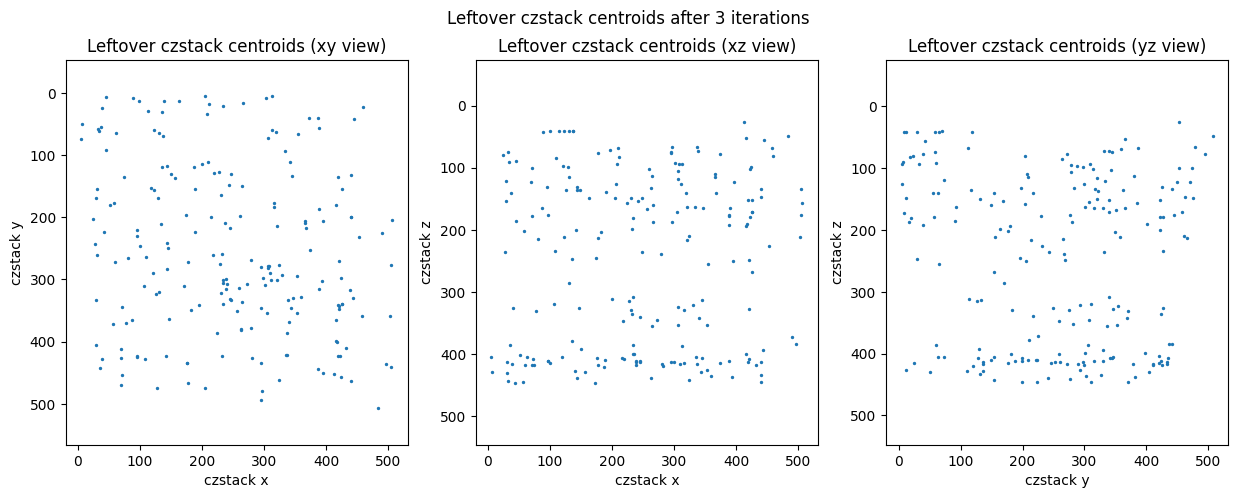

In [6]:
# plot density of leftover czstack centroids from 3 different views
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].scatter(leftover_czstack_cell_centroids[:,0], leftover_czstack_cell_centroids[:,1], s=2)
axs[0].set_xlabel('czstack x')
axs[0].set_ylabel('czstack y')
axs[0].set_title('Leftover czstack centroids (xy view)')
axs[1].scatter(leftover_czstack_cell_centroids[:,0], leftover_czstack_cell_centroids[:,2], s=2)
axs[1].set_xlabel('czstack x')
axs[1].set_ylabel('czstack z')
axs[1].set_title('Leftover czstack centroids (xz view)')
axs[2].scatter(leftover_czstack_cell_centroids[:,1], leftover_czstack_cell_centroids[:,2], s=2)
axs[2].set_xlabel('czstack y')
axs[2].set_ylabel('czstack z')
axs[2].set_title('Leftover czstack centroids (yz view)')
for ax in axs:
    # make the origin at the upper left corner
    ax.invert_yaxis()
    ax.axis('equal')
fig.suptitle(f'Leftover czstack centroids after {prev_iter} iterations')
plt.show()

This shows that the leftover after the 2nd iteration is not only at the edges

In [9]:
# process spot counts df

matched_spot_counts = spot_488_counts.loc[matched_hcr_ids]
nonmatched_spot_counts = spot_488_counts.drop(index=matched_hcr_ids)

filter_rate = 1.2

if filter_hcr_rois:
    print('Filtering non-matched HCR ROIs based on spot counts and density thresholds...')
    min_counts_threshold = matched_spot_counts['count'].min() * filter_rate
    min_density_threshold = matched_spot_counts['density'].min() * filter_rate
    leftover_spot_counts = nonmatched_spot_counts.query('count >= @min_counts_threshold and density >= @min_density_threshold')
else:
    print('Not filtering non-matched HCR ROIs...')
    leftover_spot_counts = nonmatched_spot_counts
leftover_HCR_df = pd.merge(leftover_spot_counts, HCR_cell_centroids_df, left_index=True, right_index=True, how='inner')


Filtering non-matched HCR ROIs based on spot counts and density thresholds...


In [10]:
# One-to-One Matching Algorithm
# Solves the many-to-one problem by iteratively assigning best matches

def one_to_one_matching(HCR_centroids_est, leftover_HCR_df):
    """
    Solve one-to-one matching from distance matrix.
    
    Parameters:
    -----------
    HCR_centroids_est : ndarray of shape (M, 3)
        Estimated HCR centroids from leftover czstack centroids
    leftover_HCR_df : DataFrame of shape (N, 3)
        DataFrame containing leftover HCR centroids with columns ['hcr_x', 'hcr_y', 'hcr_z']
    
    Returns:
    --------
    matched_indices : ndarray of shape (M,)
        Index of matched target point for each source point (-1 if unmatched)
    matched_distances : ndarray of shape (M,)
        Distance to matched target point for each source point (inf if unmatched)
    dist_matrix : ndarray of shape (M, N)
        Pairwise distance matrix between source and target points
    """
    dist_matrix = distance_matrix(HCR_centroids_est, leftover_HCR_df[['hcr_x','hcr_y','hcr_z']].values)
    M, N = dist_matrix.shape
    
    # Initialize output arrays
    matched_indices = np.full(M, -1, dtype=int)
    matched_distances = np.full(M, np.inf)
    
    # Keep track of which target points are already assigned
    used_targets = np.zeros(N, dtype=bool)
    
    # Create a copy of distance matrix that we can modify
    working_dist_matrix = dist_matrix.copy()
    
    # Process matches iteratively
    for iteration in range(min(M, N)):
        # Find the global minimum in the remaining matrix
        flat_idx = np.argmin(working_dist_matrix)
        source_idx, target_idx = np.unravel_index(flat_idx, working_dist_matrix.shape)
        
        # Record this match
        matched_indices[source_idx] = target_idx
        matched_distances[source_idx] = working_dist_matrix[source_idx, target_idx]
        
        # Mark this target as used
        used_targets[target_idx] = True
        
        # Remove this source row and target column from consideration
        working_dist_matrix[source_idx, :] = np.inf
        working_dist_matrix[:, target_idx] = np.inf
    
    return matched_indices, matched_distances, dist_matrix



In [7]:
def choose_max_count_nearest_neighbor(HCR_centroids_est, leftover_HCR_df, 
                                      feature='density', k=5, resolve_duplicates=True):
    """ Choose nearest neighbor with maximum spot counts among k nearest candidates.
    If resolve_duplicates is True, attempt to resolve many-to-one matches by reassigning duplicates

    Parameters:
    -----------
    HCR_centroids_est : ndarray of shape (M, 3)
        Estimated HCR centroids from leftover czstack centroids
    leftover_HCR_df : DataFrame of shape (N, 3)
        DataFrame containing leftover HCR centroids with columns ['hcr_x', 'hcr_y', 'hcr_z']
    feature : str
        Feature to use for matching. 'count' or 'density'
    k : int
        Number of nearest neighbors to consider
    resolve_duplicates : bool
        Whether to attempt to resolve many-to-one matches
    Returns:
    --------
    chosen_indices : ndarray of shape (M,)
        Index of matched target point for each source point (-1 if unmatched)
    chosen_distances : ndarray of shape (M,)
        Distance to matched target point for each source point (inf if unmatched)
    dist_matrix : ndarray of shape (M, N)
        Pairwise distance matrix between source and target points
    resolve_duplicates : bool
        Whether to attempt to resolve many-to-one matches
    Returns:
    --------
    chosen_indices : ndarray of shape (M,)
        Index of matched target point for each source point (-1 if unmatched)
    chosen_distances : ndarray of shape (M,)
        Distance to matched target point for each source point (inf if unmatched)
    dist_matrix : ndarray of shape (M, N)
        Pairwise distance matrix between source and target points
    """
    hcr_centroids = leftover_HCR_df[['hcr_x','hcr_y','hcr_z']].to_numpy()
    counts = leftover_HCR_df[feature].to_numpy()

    dist_matrix = distance_matrix(HCR_centroids_est, hcr_centroids)
    k = min(k, dist_matrix.shape[1])

    # Indices of k smallest distances per source (row)
    nearest_indices = np.argpartition(dist_matrix, k, axis=1)[:, :k]
    nearest_distances = np.take_along_axis(dist_matrix, nearest_indices, axis=1)

    # Counts for those candidates
    nearest_counts = counts[nearest_indices]

    # Pick candidate with max counts per row
    best_local_idx = np.argmax(nearest_counts, axis=1)
    row_idx = np.arange(nearest_indices.shape[0])
    chosen_indices = nearest_indices[row_idx, best_local_idx]
    chosen_distances = nearest_distances[row_idx, best_local_idx]

    # Detect many-to-one
    # targets mapped multiple times
    _, inverse, counts_per_target = np.unique(chosen_indices, return_inverse=True, return_counts=True)
    duplicate_sources_mask = counts_per_target[inverse] > 1

    if resolve_duplicates and duplicate_sources_mask.any():
        print(f'Resolving {np.sum(duplicate_sources_mask)} duplicate matches...')
        # Keep only the source with minimal distance for each duplicated target
        # For duplicates: build per-target minimal distance
        keep_mask = np.ones_like(chosen_indices, dtype=bool)
        dup_targets = np.unique(chosen_indices[duplicate_sources_mask])
        for t in dup_targets:
            sel = np.where(chosen_indices == t)[0]
            best = sel[np.argmin(chosen_distances[sel])]
            sel_remove = sel[sel != best]
            keep_mask[sel_remove] = False

        # Optionally attempt second-best for removed rows (still within their k candidates)
        removed_rows = np.where(~keep_mask)[0]
        if len(removed_rows):
            # For each removed row choose next best (by counts) that is not already taken
            taken = set(chosen_indices[keep_mask])
            # Mask out previously chosen best
            nearest_counts_removed = nearest_counts[removed_rows].copy()
            nearest_counts_removed[np.arange(len(removed_rows)), best_local_idx[removed_rows]] = -1
            # Iterate only over removed rows (small set)
            for j, r in enumerate(removed_rows):
                # Sort candidates by counts descending
                cand_order = np.argsort(-nearest_counts_removed[j])
                for cand_pos in cand_order:
                    cand_target = nearest_indices[r, cand_pos]
                    if cand_target not in taken:
                        chosen_indices[r] = cand_target
                        chosen_distances[r] = nearest_distances[r, cand_pos]
                        taken.add(cand_target)
                        break
                else:
                    # Could not find alternative unique target; mark unmatched
                    chosen_indices[r] = -1
                    chosen_distances[r] = np.inf

    return chosen_indices, chosen_distances, dist_matrix

In [8]:
leftover_HCR_df

,channel,sum,count,density,background,hcr_z,hcr_y,hcr_x
2,488,26100.0,269,97.026024,93.0,163,267,71
3,488,100834.0,1043,96.676895,93.0,163,279,71
4,488,18934.0,195,97.097435,93.0,164,276,75
5,488,61288.0,635,96.516530,93.0,165,286,72
8,488,87648.0,907,96.635060,93.0,167,286,77
...,...,...,...,...,...,...,...,...
84228,488,783620.0,6899,113.584580,97.0,1400,1739,1825
84229,488,6667.0,67,99.507460,94.0,1401,1775,1783
84230,488,21779.0,227,95.942730,97.0,1406,1722,1842
84232,488,434789.0,4300,101.113720,94.0,1407,1777,1794


Filtering non-matched HCR ROIs based on spot counts and density thresholds...


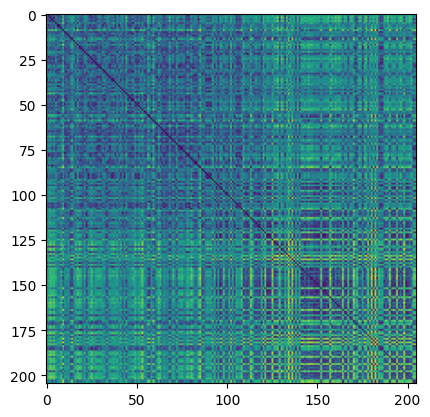

In [11]:
if filter_hcr_rois:
    print('Filtering non-matched HCR ROIs based on spot counts and density thresholds...')
    final_matched_indices, final_matched_distances, dist_matrix = \
        one_to_one_matching(HCR_centroids_est, leftover_HCR_df)
else:
    print('Not filtering non-matched HCR ROIs...')
    final_matched_indices, final_matched_distances, dist_matrix = \
        choose_max_count_nearest_neighbor(HCR_centroids_est, leftover_HCR_df, feature='density',
            k=5, resolve_duplicates=True)

sort_order = np.argsort(final_matched_distances)
    
# Create matrix with matched sources (rows) and their assigned targets (columns)
sorted_sources = np.arange(len(final_matched_indices))[sort_order]
sorted_targets = final_matched_indices[sort_order]
sorted_dists = final_matched_distances[sort_order]

# Extract relevant distances for visualization
matched_dist_matrix = dist_matrix[np.ix_(sorted_sources, sorted_targets)]

plt.imshow(matched_dist_matrix)



In [12]:
# assign matching to matched_cells_df
new_matched_hcr_df = leftover_HCR_df.iloc[final_matched_indices].reset_index().copy().rename(columns={'index':'hcr_cell_id'})
new_matched_hcr_df['distance'] = final_matched_distances
new_matched_hcr_df['czstack_cell_id'] = leftover_czstack_ids
new_matched_hcr_df['czstack_x'] = leftover_czstack_df['czstack_x'].values
new_matched_hcr_df['czstack_y'] = leftover_czstack_df['czstack_y'].values
new_matched_hcr_df['czstack_z'] = leftover_czstack_df['czstack_z'].values
new_matched_hcr_df.sort_values(by='distance', inplace=True)
new_matched_hcr_df.head()


,hcr_cell_id,channel,sum,count,density,background,hcr_z,hcr_y,hcr_x,distance,czstack_cell_id,czstack_x,czstack_y,czstack_z
102,15033,488,616004.0,4947,124.52072,111.0,624,874,738,1.245635,245,425.701571,339.486911,151.202443
55,14658,488,8050294.0,4281,1880.47050,113.0,619,658,1199,3.370868,143,69.794624,470.338710,123.112903
11,4100,488,3343848.0,3111,1074.84670,101.0,437,673,929,3.694226,19,296.720795,479.325076,66.233486
26,9029,488,756027.0,2306,327.85210,102.0,537,917,1185,3.938274,71,109.918182,264.272314,84.489876
23,5768,488,1217049.0,5431,224.09299,106.0,471,663,918,4.313810,62,294.927273,494.453030,76.985354


In [14]:
save_fn = save_dir / f'{subject_id}_landmarks_matched_ext_iter{current_iter}.csv'
# assert not save_fn.exists(), f'File already exists: {save_fn}'
landmarks_ext = pd.DataFrame()

landmarks_ext[0] = ['cz'+str(int(new_matched_hcr_df['czstack_cell_id'].iloc[i]))+'-hcr'+str(int(new_matched_hcr_df['hcr_cell_id'].iloc[i])) for i in range(len(new_matched_hcr_df))]

landmarks_ext[1] = False
landmarks_ext[2] = new_matched_hcr_df['czstack_x'].values
landmarks_ext[3] = new_matched_hcr_df['czstack_y'].values
landmarks_ext[4] = new_matched_hcr_df['czstack_z'].values
landmarks_ext[5] = new_matched_hcr_df['hcr_x'].values * scale_x
landmarks_ext[6] = new_matched_hcr_df['hcr_y'].values * scale_y
landmarks_ext[7] = new_matched_hcr_df['hcr_z'].values * scale_z

columns = np.arange(8)
landmarks.columns = columns
landmarks_ext = pd.concat([landmarks_ext, landmarks])

landmarks_ext.to_csv(save_fn, index=False, header=False)
landmarks_ext.head()

,0,1,2,3,4,5,6,7
0,cz245-hcr15033,False,425.701571,339.486911,151.202443,728.062217,862.230864,624.0
1,cz143-hcr14658,False,69.794624,470.338710,123.112903,1182.854469,649.139484,619.0
2,cz19-hcr4100,False,296.720795,479.325076,66.233486,916.490244,663.937496,437.0
3,cz71-hcr9029,False,109.918182,264.272314,84.489876,1169.042991,904.651833,537.0
4,cz62-hcr5768,False,294.927273,494.453030,76.985354,905.638368,654.072154,471.0


In [12]:
landmarks_ext

,0,1,2,3,4,5,6,7
0,cz440-hcr37364,False,380.672528,433.285385,250.341885,753.712106,700.439260,833.0
1,cz582-hcr63313,False,145.287602,251.492886,313.943598,1071.376108,873.082740,1012.0
2,cz565-hcr62482,False,106.275271,309.234686,308.454248,1117.743214,797.119609,1004.0
3,cz424-hcr44447,False,129.243594,56.950083,241.652246,1144.379637,1130.568158,883.0
4,cz501-hcr54955,False,55.058752,421.845777,283.009486,1176.935264,651.112552,948.0
...,...,...,...,...,...,...,...,...
796,cz0761-hcr80468,True,43.484519,268.872469,392.364519,1173.975662,799.092677,1224.0
797,cz0762-hcr78862,True,177.932848,352.017652,391.015469,990.480306,729.048751,1193.0
798,cz0763-hcr78356,True,147.723214,394.840608,387.165344,1019.089797,675.775906,1185.0
799,cz0764-hcr76985,True,196.497238,220.429098,381.546961,990.480306,893.799958,1163.0


In [13]:
# add qc from another 
qced_csv = save_dir / f'{subject_id}_landmarks_matched_ext_iter{current_iter}_temp.csv'
qced_landmarks = pd.read_csv(qced_csv, header=None)
matched_pairs = qced_landmarks[qced_landmarks[1]][0].values
landmarks_ext[1] = landmarks_ext[0].isin(matched_pairs)

In [15]:
landmarks_ext.to_csv(save_fn, index=False, header=False)

In [52]:
def _get_hcr_id(x):
    if x.startswith('cz'):
        return int(x.split('-hcr')[-1])
    else:
        return -1
landmarks_ext['hcr_id'] = landmarks_ext[0].apply(_get_hcr_id)

In [53]:
pd.DataFrame(landmarks_ext.query('hcr_id != -1').hcr_id.value_counts()).query('count == 2')

,count
hcr_id,


# Checking number of mapped IDs

In [23]:
landmarks_path = save_dir / f'{subject_id}_landmarks_matched_ext_iter4.csv'
landmarks = pd.read_csv(landmarks_path, header=None)
print(len(landmarks))
columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
landmarks.columns = columns
landmarks = landmarks.query('active')

zstack_ids, hcr_ids = get_ids_from_landmarks(landmarks)
matched_czstack_ids, matched_hcr_ids = get_ids_from_landmarks(landmarks)

print(f'matched cells: {len(matched_czstack_ids)}')
# print(f'New estimation: {HCR_centroids_est.shape[0]}')
# print(f'{HCR_centroids_est.shape[0] / (len(matched_czstack_ids) + HCR_centroids_est.shape[0]) * 100:.1f}% of total czstack cells have been matched after {current_iter} iterations')


852
matched cells: 639


In [25]:
639/852

0.75